In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("files/estilo_de_vida_salud.csv")
df.sample()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
727,58,101,159,medium,9.6,low,no,no,no,driver,40.0,high


### filtramos los df por riesgo de salud

In [3]:
df_high = df[df["health_risk"] == "high"]
df_high.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high
5,25,96,160,medium,3.8,medium,no,no,yes,farmer,37.5,high


In [4]:
df_low = df[df["health_risk"] == "low"]
df_low.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
8,56,58,158,medium,9.6,medium,no,no,yes,office_worker,23.2,low
12,28,68,194,medium,10.0,medium,no,yes,no,office_worker,18.1,low
13,28,66,168,low,6.6,medium,no,no,yes,farmer,23.4,low
18,41,52,192,high,8.5,medium,yes,no,no,student,14.1,low


### Analizamos si existen Outliers

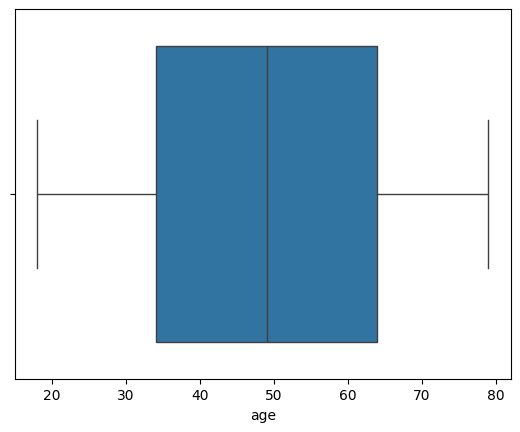

In [35]:
sns.boxplot(data=df, x="age");

Comparamos si fuman

In [5]:
df_low["smoking"].value_counts(normalize=True)*100

smoking
no     95.695364
yes     4.304636
Name: proportion, dtype: float64

In [6]:
df_high["smoking"].value_counts(normalize=True)*100

smoking
no     73.868195
yes    26.131805
Name: proportion, dtype: float64

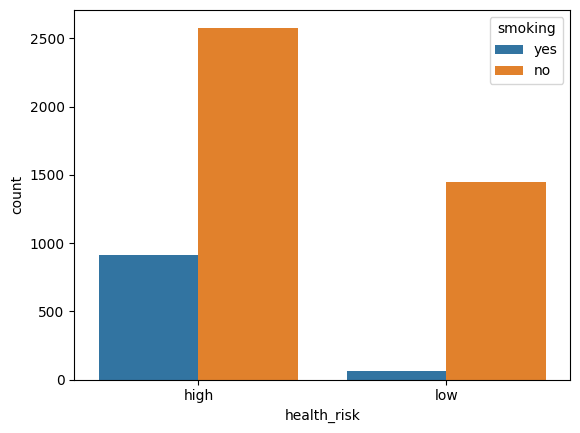

In [13]:
sns.countplot(data=df, x="health_risk", hue="smoking");

Mientras que el 65% de quienes no consumen alcohol no presentan alto riesgo, esta cifra asciende a mas del 84% entre quienes si consumen, evidenciando una fuerte asociación entre el consumo de alcohol y un mayor riesgo de salud

In [27]:
cross_al = pd.crosstab([df['alcohol']], df['health_risk'], normalize="index")*100
cross_al

health_risk,high,low
alcohol,,
no,64.982625,35.017375
yes,84.114376,15.885624


Comparando el porcentaje de los que fuman de los que SI fuman 93% tienen riesgo alto y de los que NO fuman el 64.98% tienen riesgo alto

In [29]:
cross_al = pd.crosstab([df['smoking']], df['health_risk'], normalize="index")*100
cross_al

health_risk,high,low
smoking,,
no,64.081531,35.918469
yes,93.346981,6.653019


NO vemos un patron aparente

In [30]:
cross_mr = pd.crosstab([df['married']], df['health_risk'], normalize="index")*100
cross_mr

health_risk,high,low
married,,
no,70.887992,29.112008
yes,69.085487,30.914513
